<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/BA820_Team6_Project_M4_Xiaoxuan_Zhu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Data Preparation

In [2]:
from google.colab import files
uploaded = files.upload()

Saving cats_uk_reference.csv to cats_uk_reference.csv
Saving cats_uk.csv to cats_uk.csv


In [3]:
import pandas as pd
events = pd.read_csv("cats_uk.csv")

COL = {
    "cat_id": "tag_id",
    "timestamp": "timestamp",
    "speed": "ground_speed",
    "lat": "location_lat",
    "lon": "location_long"
}

df = events.copy()
df = df.dropna(subset=[COL["cat_id"], COL["speed"]])
df[COL["speed"]] = pd.to_numeric(df[COL["speed"]], errors="coerce")
df = df.dropna(subset=[COL["speed"]])
df = df[df[COL["speed"]] >= 0]

print("df shape:", df.shape)

df shape: (18215, 11)


## 2.  Feature Construction

In [4]:
import numpy as np
g = df.groupby(COL["cat_id"])

features = g[COL["speed"]].agg(
    n_obs="size",
    mean_speed="mean",
    median_speed="median",
    max_speed="max",
    p75_speed=lambda s: np.percentile(s, 75),
    p95_speed=lambda s: np.percentile(s, 95),
).reset_index().rename(columns={COL["cat_id"]: "tag_id"})

In [5]:
span = g.agg(
    lat_min=(COL["lat"], "min"),
    lat_max=(COL["lat"], "max"),
    lon_min=(COL["lon"], "min"),
    lon_max=(COL["lon"], "max"),
).reset_index().rename(columns={COL["cat_id"]: "tag_id"})

span["lat_span"] = span["lat_max"] - span["lat_min"]
span["lon_span"] = span["lon_max"] - span["lon_min"]

span = span[["tag_id", "lat_span", "lon_span"]]

In [6]:
df["_ts"] = pd.to_datetime(df[COL["timestamp"]], errors="coerce", utc=True)
df["_hour"] = df["_ts"].dt.hour

df["_is_day"] = ((df["_hour"] >= 6) & (df["_hour"] < 18)).astype(int)

day = df.groupby(COL["cat_id"])["_is_day"].mean().reset_index()
day = day.rename(columns={COL["cat_id"]: "tag_id", "_is_day": "day_ratio"})

In [7]:
features = features.merge(span, on="tag_id", how="left").merge(day, on="tag_id", how="left")

print(features.shape)
display(features.head())

(101, 10)


,tag_id,n_obs,mean_speed,median_speed,max_speed,p75_speed,p95_speed,lat_span,lon_span,day_ratio
0,Abba-Tag,83,1603.951807,864.0,13968,1746.0,5763.6,0.003963,0.010782,0.361446
1,Alfie-Tag,187,1931.679144,1188.0,14652,2358.0,5752.8,0.004066,0.012550,0.395722
2,Amber-Tag,218,1967.614679,1188.0,21888,2475.0,6438.6,0.030289,0.040155,0.655963
3,Ares,103,2285.825243,1440.0,14328,2898.0,7891.2,0.002487,0.003378,0.213592
4,Athena,106,2134.188679,1494.0,19728,2862.0,5715.0,0.002319,0.003988,0.452830


In [8]:
feature_cols = features.columns.drop("tag_id").tolist()

print("features columns:", list(features.columns))
print("model features:", feature_cols)

features columns: ['tag_id', 'n_obs', 'mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio']
model features: ['n_obs', 'mean_speed', 'median_speed', 'max_speed', 'p75_speed', 'p95_speed', 'lat_span', 'lon_span', 'day_ratio']


## 3. Feature Standardization

In [9]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "n_obs",
    "mean_speed", "median_speed", "max_speed",
    "p75_speed", "p95_speed",
    "lat_span", "lon_span",
    "day_ratio"
]

X = features[feature_cols].copy()
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape:", X_scaled.shape)

Shape: (101, 9)


### PCA(Explained Variance & Projection)

In [10]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA()
pca.fit(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print("Explained variance ratio (first 5):", explained[:5])
print("Cumulative variance (first 5):", cum_explained[:5])

Explained variance ratio (first 5): [0.38459929 0.25952038 0.13628218 0.09688972 0.0605746 ]
Cumulative variance (first 5): [0.38459929 0.64411967 0.78040185 0.87729157 0.93786617]


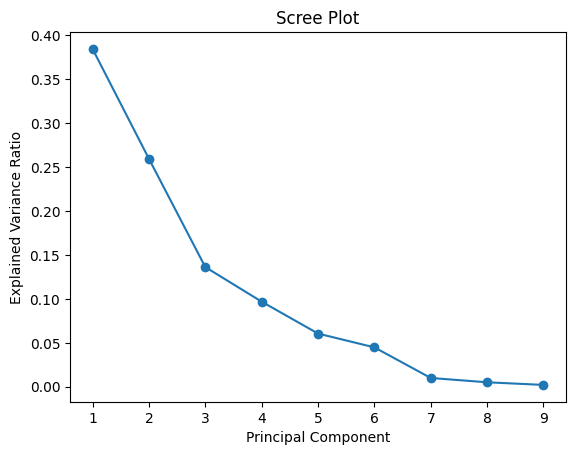

In [11]:
plt.figure()
plt.plot(range(1, len(explained)+1), explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

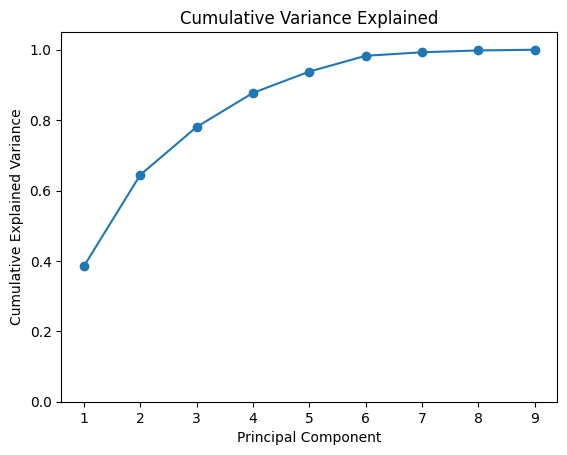

In [12]:
plt.figure()
plt.plot(range(1, len(cum_explained)+1), cum_explained, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained")
plt.ylim(0, 1.05)
plt.show()

In [13]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))]
)

display(loadings[["PC1", "PC2"]].sort_values("PC1", ascending=False))

,PC1,PC2
mean_speed,0.513184,0.128407
p75_speed,0.496239,0.030514
median_speed,0.485394,-0.043573
p95_speed,0.436791,0.075438
max_speed,0.065770,0.419983
lat_span,-0.021378,0.577082
lon_span,-0.036092,0.568581
day_ratio,-0.063427,0.191331
n_obs,-0.232137,0.325099


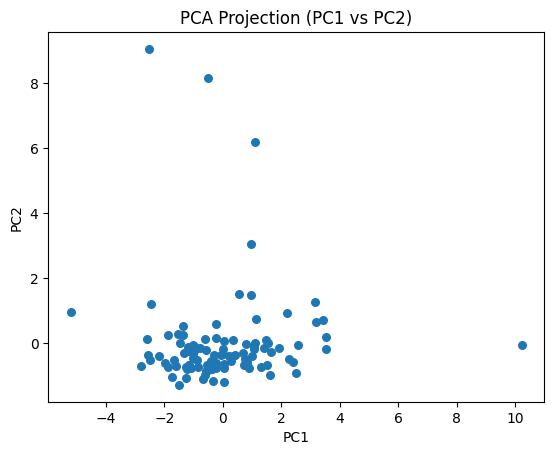

In [14]:
pca2 = PCA(n_components=2)
Z = pca2.fit_transform(X_scaled)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], s=30)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.show()

### K-Means on Reduced Dimension (PC1-only)

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pc1 = pca.transform(X_scaled)[:, 0].reshape(-1, 1)
for k in [2, 3]:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(pc1)
    sil = silhouette_score(pc1, labels)
    sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"PC1-only KMeans k={k}: silhouette={sil:.3f}, sizes={sizes}")

PC1-only KMeans k=2: silhouette=0.576, sizes={0: 66, 1: 35}
PC1-only KMeans k=3: silhouette=0.576, sizes={0: 39, 1: 61, 2: 1}


### Hierarchical Clustering Comparison

In M2, a three-cluster solution was initially explored based on silhouette comparison. However, further inspection in M4 revealed that the third cluster contained only a very small number of observations and did not represent a stable or interpretable behavioral pattern. Therefore, for the final profiling and interpretation, we focus on the two-cluster solution, which provides clearer separation and stronger practical interpretability.

In [26]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# KMeans (k=3) — M2 choice
labels_k3 = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(X_scaled)

# Hierarchical (k=2) — M2 best silhouette
labels_h2 = AgglomerativeClustering(n_clusters=2, linkage="ward").fit_predict(X_scaled)

sil_h2 = silhouette_score(X_scaled, labels_h2)
print(f"Hierarchical k=2 silhouette={sil_h2:.3f}")

Hierarchical k=2 silhouette=0.643


## 4.Cluster Visualization in PCA Space

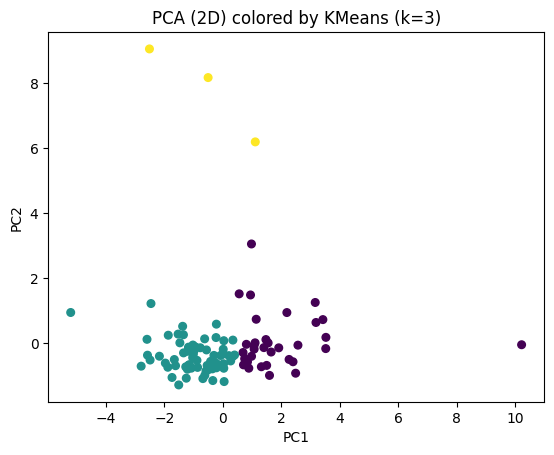

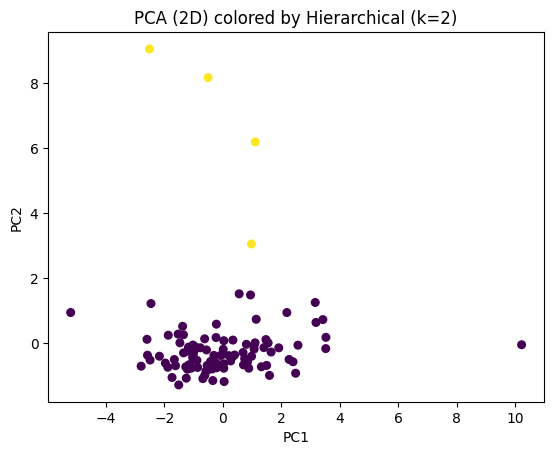

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Z = PCA(n_components=2).fit_transform(X_scaled)

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=labels_k3, s=30)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA (2D) colored by KMeans (k=3)")
plt.show()

plt.figure()
plt.scatter(Z[:,0], Z[:,1], c=labels_h2, s=30)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA (2D) colored by Hierarchical (k=2)")
plt.show()

### PCA Interpretation

In [18]:
loadings_pc1 = loadings["PC1"].sort_values(key=np.abs, ascending=False)
loadings_pc2 = loadings["PC2"].sort_values(key=np.abs, ascending=False)

print("Top PC1 loadings:")
display(loadings_pc1.head(6))

print("Top PC2 loadings:")
display(loadings_pc2.head(6))

Top PC1 loadings:


,PC1
mean_speed,0.513184
p75_speed,0.496239
median_speed,0.485394
p95_speed,0.436791
n_obs,-0.232137
max_speed,0.065770


Top PC2 loadings:


,PC2
lat_span,0.577082
lon_span,0.568581
max_speed,0.419983
n_obs,0.325099
day_ratio,0.191331
mean_speed,0.128407


## 5.Cluster Profiling & Interpretation

### Median Profile

In [25]:
import pandas as pd
from sklearn.cluster import KMeans

labels2 = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(X_scaled)

profile = features.loc[X.index].copy()
profile["cluster2"] = labels2

summary = profile.groupby("cluster2")[feature_cols].median().T
display(summary)

cluster2,0,1
n_obs,174.000000,104.500000
mean_speed,1670.079208,2539.927340
median_speed,1008.000000,1458.000000
max_speed,16056.000000,24804.000000
p75_speed,2106.000000,2871.000000
p95_speed,5320.800000,7989.300000
lat_span,0.004158,0.004977
lon_span,0.004891,0.006992
day_ratio,0.378947,0.367392


### Standardized (Z-score) Summary

In [22]:
Z_df = pd.DataFrame(X_scaled, index=X.index, columns=feature_cols)
Z_df["cluster2"] = labels2

z_summary = Z_df.groupby("cluster2")[feature_cols].mean().T
display(z_summary)

cluster2,0,1
n_obs,0.110609,-0.199710
mean_speed,-0.573277,1.035083
median_speed,-0.435745,0.786763
max_speed,-0.235015,0.424334
p75_speed,-0.472842,0.853743
p95_speed,-0.517283,0.933983
lat_span,-0.082782,0.149468
lon_span,-0.057402,0.103642
day_ratio,0.029181,-0.052688


### Cluster Distribution Visualization

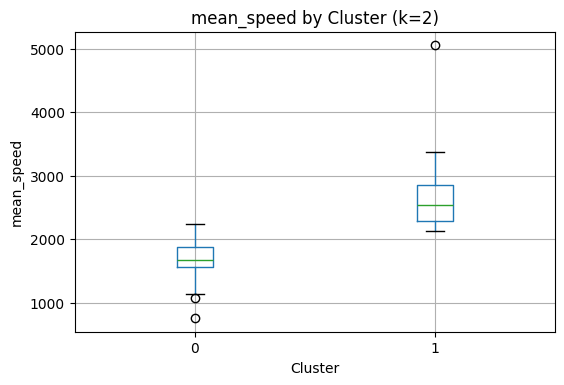

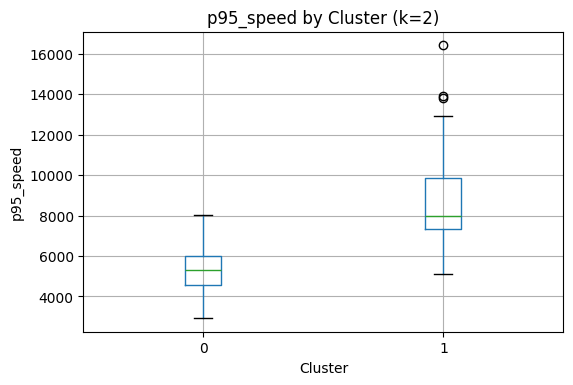

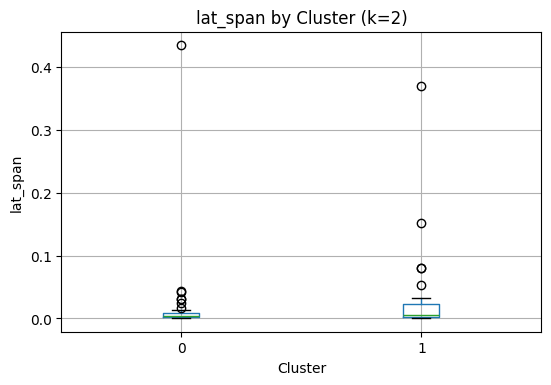

In [23]:
import matplotlib.pyplot as plt

for col in ["mean_speed", "p95_speed", "lat_span"]:
    ax = profile.boxplot(column=col, by="cluster2", figsize=(6,4))
    plt.title(f"{col} by Cluster (k=2)")
    plt.suptitle("")
    plt.xlabel("Cluster")
    plt.ylabel(col)
    plt.show()

## 6. Final Remark

The clustering results are internally consistent and stable. The two-cluster solution captures a clear behavioral separation, primarily along overall movement intensity. PCA diagnostics indicate that most variation is driven by speed-related features, and clustering results remain highly similar whether using the full feature space or reduced dimensions. Together, these findings suggest that extreme movement patterns are not random noise, but reflect systematic differences in behavioral profiles.